**Integrantes:**
* WINSTON GEOVANNI QUINDE PEZO
* JAVIER SEBASTIAN GUILLEN NAREA
* RAFAEL ALEXANDER SANTILLAN VINCES

**MINERÍA DE DATOS GRUPO - 1**

# FACTORES ASOCIADOS A LA DESERCIÓN O DESMOTIVACIÓN ESTUDIANTIL DE UNA UNIVERSIDAD DEL ECUADOR

# Instrucciones básicas de uso
Para ejecutar, simplemente sube el archivo dataset.xlsx a tu entorno de Colab y ejecuta todas las celdas


# limpieza

In [1]:
import pandas as pd, re, numpy as np
df = pd.read_excel('dataset.xlsx')
df.columns = df.columns.str.strip()


In [2]:

def normalizar_semestre(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    s = s.replace('semetre','semestre')
    m = re.search(r'\d+', s)
    if m:
        return int(m.group())
    palabras = {
        'primero':1,'primer':1,
        'segundo':2,
        'tercero':3,'tercer':3,
        'cuarto':4,
        'quinto':5,
        'sexto':6,
        'septimo':7,'séptimo':7,
        'octavo':8,
        'noveno':9,
        'decimo':10,'décimo':10,
    }
    return palabras.get(s, np.nan)

df['Semestre_norm'] = df['Semestre que cursas actualmente:'].apply(normalizar_semestre)
df['Semestre que cursas actualmente:'].head(20), df['Semestre_norm'].head(20)


(0                     8
 1                    10
 2                Quinto
 3                     5
 4                  5to 
 5                   7mo
 6                     5
 7               Septimo
 8           7 semestre 
 9     Séptimo semestre 
 10                  7mo
 11               Quinto
 12                    7
 13                    7
 14               Cuarto
 15                  7mo
 16             Séptimo 
 17    Séptimo semestre 
 18                    6
 19                Sexto
 Name: Semestre que cursas actualmente:, dtype: object,
 0      8.0
 1     10.0
 2      5.0
 3      5.0
 4      5.0
 5      7.0
 6      5.0
 7      7.0
 8      7.0
 9      NaN
 10     7.0
 11     5.0
 12     7.0
 13     7.0
 14     4.0
 15     7.0
 16     7.0
 17     NaN
 18     6.0
 19     6.0
 Name: Semestre_norm, dtype: float64)

In [3]:
def normalizar_semestre(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    s = s.replace('semetre','semestre')
    m = re.search(r'\d+', s)
    if m:
        return int(m.group())
    palabras = {
        'primero':1,'primer':1,
        'segundo':2,
        'tercero':3,'tercer':3,
        'cuarto':4,
        'quinto':5,
        'sexto':6,
        'septimo':7,'séptimo':7,
        'octavo':8,
        'noveno':9,
        'decimo':10,'décimo':10,
    }
    for token in re.split(r'\s+', s):
        if token in palabras:
            return palabras[token]
    return np.nan

df['Semestre_norm'] = df['Semestre que cursas actualmente:'].apply(normalizar_semestre)
df[['Semestre que cursas actualmente:','Semestre_norm']].head(20)


,Semestre que cursas actualmente:,Semestre_norm
0,8,8
1,10,10
2,Quinto,5
3,5,5
4,5to,5
5,7mo,7
6,5,5
7,Septimo,7
8,7 semestre,7
9,Séptimo semestre,7


In [4]:
def normalizar_promedio(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(',', '.')
    try:
        val = float(s)
    except ValueError:
        return np.nan
    if val > 10:
        val = val / 10.0
    return val

df['Promedio_norm'] = df['Promedio general (1-10) :  '.strip()].apply(normalizar_promedio)
df[['Promedio general (1-10) :'.strip(),'Promedio_norm']].head(10)


,Promedio general (1-10) :,Promedio_norm
0,7.68,7.68
1,8,8.00
2,80,8.00
3,90,9.00
4,96,9.60
5,8,8.00
6,78,7.80
7,8,8.00
8,8,8.00
9,75,7.50


In [5]:
df['Carrera:'].nunique(), df['Carrera:'].value_counts().head(20)


(93,
 Carrera:
 Administración de empresas       23
 Mecatrónica                      17
 Computación                      15
 Electricidad                     14
 Mecatronica                      13
 Ingeniería automotriz            13
 Automotriz                       11
 Biomedicina                      10
 Mecatronica                       8
 Administración de Empresas        6
 Automotriz                        6
 Ingeniería industrial             6
 Ing automotriz                    6
 Ingeniería Automotriz             6
 Mecatrónica                       5
 Ing Automotriz                    4
 Electrónica y Automatización      4
 Electricidad                      4
 Computacion                       4
 Ing. Automotriz                   3
 Name: count, dtype: int64)

In [6]:
# see some tail values
df['Carrera:'].value_counts().tail(20)


,count
Carrera:,
ingeniería industrial,1
Ing Industrial,1
Mecánico,1
Ing Mecatronica,1
Ing. Mecatronica,1
Electronica,1
Ingenieria Electronica y Automatizacion,1
Ing eléctrica,1
Ing en puteria,1


In [7]:
import unicodedata
def quitar_acentos(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

def normalizar_carrera(x):
    if pd.isna(x):
        return np.nan
    s = quitar_acentos(str(x)).strip().lower()
    # reglas por palabras clave
    if 'comput' in s or ('ti' in s and 'ingenieria' in s):
        return 'Ingeniería en Computación / TI'
    if 'mecatron' in s:
        return 'Ingeniería Mecatrónica'
    if 'automotriz' in s or 'automotriz' in s or 'automotriz' in s:
        return 'Ingeniería Automotriz'
    if 'electric' in s:
        return 'Ingeniería Eléctrica'
    if 'electronica' in s and 'automat' in s:
        return 'Ingeniería Electrónica y Automatización'
    if 'industrial' in s:
        return 'Ingeniería Industrial'
    if 'administracion' in s or 'administration' in s or 'adm. empresa' in s or 'administracion de empresas' in s:
        return 'Administración de Empresas'
    if 'contabilidad' in s:
        return 'Contabilidad y Auditoría'
    if 'biomedicina' in s:
        return 'Ingeniería en Biomedicina'
    if 'economia' in s:
        return 'Economía'
    # si no cae en ninguna regla, devolver con formato titulo original
    return str(x).strip().title()

df['Carrera_norm'] = df['Carrera:'].apply(normalizar_carrera)
df['Carrera_norm'].value_counts()


,count
Carrera_norm,
Ingeniería Automotriz,62
Ingeniería Mecatrónica,49
Administración de Empresas,45
Ingeniería en Computación / TI,29
Ingeniería Eléctrica,29
Ingeniería Industrial,18
Ingeniería en Biomedicina,13
Ingeniería Electrónica y Automatización,8
Contabilidad y Auditoría,7


In [8]:
# ============================================
# 3.4 Procedimiento: limpieza y normalizacion
# ============================================

import pandas as pd
import numpy as np
import re
import unicodedata

# 1) Cargar el archivo original
# (si estas en Colab, sube primero dataset.xlsx o monta tu Google Drive)
df = pd.read_excel("dataset.xlsx")

# 2) Limpiar nombres de columnas (quitar espacios extras)
df.columns = df.columns.str.strip()

# --- Funciones auxiliares ---

def quitar_acentos(s):
    """Quita acentos de una cadena."""
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

def normalizar_carrera(valor):
    """Agrupa carreras similares en categorias estandar."""
    if pd.isna(valor):
        return np.nan
    s = quitar_acentos(str(valor)).strip().lower()

    # Reglas por palabras clave (ajusta segun tus necesidades)
    if "comput" in s or ("ti" in s and "ingenieria" in s):
        return "Ingenieria en Computacion / TI"
    if "mecatron" in s:
        return "Ingenieria Mecatronica"
    if "automotriz" in s:
        return "Ingenieria Automotriz"
    if "electric" in s:
        return "Ingenieria Electrica"
    if "electronica" in s and "automat" in s:
        return "Ingenieria Electronica y Automatizacion"
    if "industrial" in s:
        return "Ingenieria Industrial"
    if "administracion" in s or "administration" in s or "adm. empresa" in s:
        return "Administracion de Empresas"
    if "contabilidad" in s:
        return "Contabilidad y Auditoria"
    if "biomedicina" in s or "biomedica" in s:
        return "Ingenieria en Biomedicina"
    if "economia" in s:
        return "Economia"

    # Si no entra en ninguna regla, se deja el texto formateado
    return str(valor).strip().title()

def normalizar_semestre(valor):
    """Convierte el semestre a numero (1..10) desde valores como '5', '5to', 'Quinto', '8vo semestre', etc."""
    if pd.isna(valor):
        return np.nan
    s = str(valor).strip().lower()
    s = s.replace("semetre", "semestre")

    # Si hay un numero en el texto, usarlo
    m = re.search(r"\d+", s)
    if m:
        return int(m.group())

    # Map de palabras a numeros
    palabras = {
        "primero": 1, "primer": 1,
        "segundo": 2,
        "tercero": 3, "tercer": 3,
        "cuarto": 4,
        "quinto": 5,
        "sexto": 6,
        "septimo": 7, "séptimo": 7,
        "octavo": 8,
        "noveno": 9,
        "decimo": 10, "décimo": 10,
    }

    for token in re.split(r"\s+", s):
        if token in palabras:
            return palabras[token]

    return np.nan

def normalizar_promedio(valor):
    """
    Normaliza el promedio:
    - Si esta entre 0 y 10 se deja igual.
    - Si esta entre 10 y 100 se divide para 10 (ej: 80 -> 8.0).
    """
    if pd.isna(valor):
        return np.nan
    s = str(valor).strip().replace(",", ".")
    try:
        val = float(s)
    except ValueError:
        return np.nan

    if val > 10:
        val = val / 10.0
    return val

def normalizar_genero(valor):
    """Limpieza simple de genero."""
    if pd.isna(valor):
        return np.nan
    s = quitar_acentos(str(valor)).strip().lower()
    if "hombre" in s or "masculino" in s:
        return "Hombre"
    if "mujer" in s or "femenino" in s:
        return "Mujer"
    return "Otro"


# 3) Aplicar normalizacion de columnas clave

# Genero
df["Genero_norm"] = df["Género"].apply(normalizar_genero)

# Carrera
df["Carrera_norm"] = df["Carrera:"].apply(normalizar_carrera)

# Semestre
df["Semestre_norm"] = df["Semestre que cursas actualmente:"].apply(normalizar_semestre)

# Promedio
df["Promedio_norm"] = df["Promedio general (1-10) :"].apply(normalizar_promedio)

# 4) Opcional: ver un resumen rapido de como quedo
print("Carreras normalizadas:")
print(df["Carrera_norm"].value_counts(), "\n")

print("Semestre normalizado (primeros 10):")
print(df[["Semestre que cursas actualmente:", "Semestre_norm"]].head(10), "\n")

print("Promedio normalizado (primeros 10):")
print(df[["Promedio general (1-10) :", "Promedio_norm"]].head(10))

# 5) Guardar dataset limpio
df.to_excel("dataset_limpio.xlsx", index=False)
print("\nArchivo 'dataset_limpio.xlsx' generado correctamente.")


Carreras normalizadas:
Carrera_norm
Ingenieria Automotriz                      62
Ingenieria Mecatronica                     49
Administracion de Empresas                 45
Ingenieria en Computacion / TI             29
Ingenieria Electrica                       29
Ingenieria Industrial                      18
Ingenieria en Biomedicina                  14
Ingenieria Electronica y Automatizacion     8
Contabilidad y Auditoria                    7
Electrónica                                 2
Economia                                    1
Ingeniería Electrónica                      1
Ing Electrónica Y Aut.                      1
Ing Automotri                               1
Mecánico                                    1
Electronica                                 1
Ing En Puteria                              1
Name: count, dtype: int64 

Semestre normalizado (primeros 10):
  Semestre que cursas actualmente:  Semestre_norm
0                                8              8
1                 

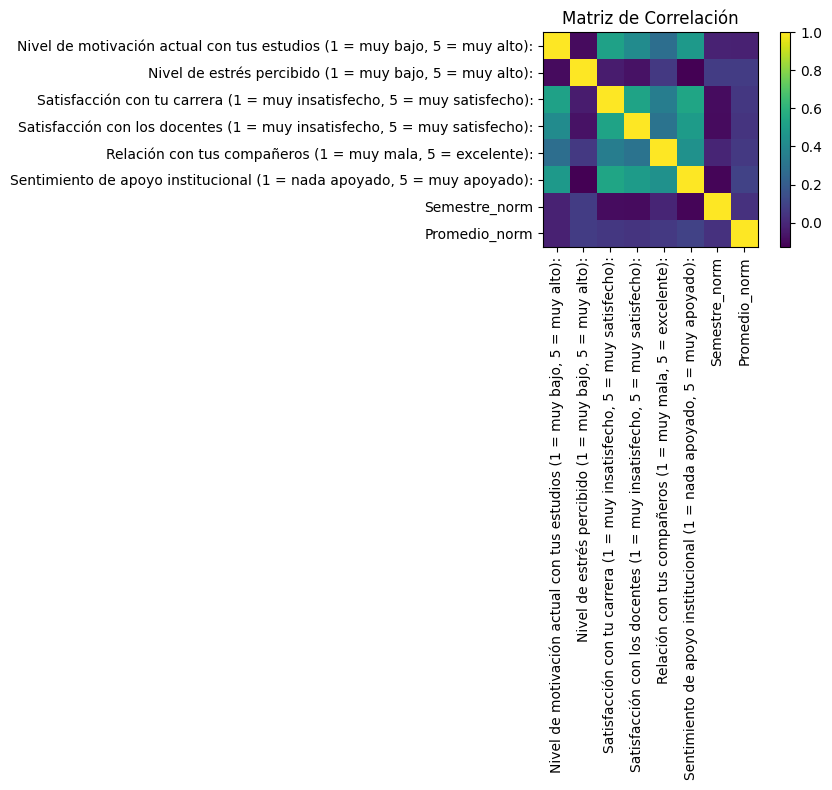

,"Nivel de motivación actual con tus estudios (1 = muy bajo, 5 = muy alto):","Nivel de estrés percibido (1 = muy bajo, 5 = muy alto):","Satisfacción con tu carrera (1 = muy insatisfecho, 5 = muy satisfecho):","Satisfacción con los docentes (1 = muy insatisfecho, 5 = muy satisfecho):","Relación con tus compañeros (1 = muy mala, 5 = excelente):","Sentimiento de apoyo institucional (1 = nada apoyado, 5 = muy apoyado):",Semestre_norm,Promedio_norm
"Nivel de motivación actual con tus estudios (1 = muy bajo, 5 = muy alto):",1.000000,-0.093751,0.517944,0.417181,0.281771,0.476977,-0.018185,-0.023573
"Nivel de estrés percibido (1 = muy bajo, 5 = muy alto):",-0.093751,1.000000,-0.042888,-0.071736,0.061054,-0.127339,0.072660,0.071042
"Satisfacción con tu carrera (1 = muy insatisfecho, 5 = muy satisfecho):",0.517944,-0.042888,1.000000,0.528210,0.351872,0.535385,-0.090229,0.057547
"Satisfacción con los docentes (1 = muy insatisfecho, 5 = muy satisfecho):",0.417181,-0.071736,0.528210,1.000000,0.300607,0.490576,-0.093132,0.040670
"Relación con tus compañeros (1 = muy mala, 5 = excelente):",0.281771,0.061054,0.351872,0.300607,1.000000,0.444815,-0.008811,0.059072
"Sentimiento de apoyo institucional (1 = nada apoyado, 5 = muy apoyado):",0.476977,-0.127339,0.535385,0.490576,0.444815,1.000000,-0.111991,0.094576
Semestre_norm,-0.018185,0.072660,-0.090229,-0.093132,-0.008811,-0.111991,1.000000,0.032182
Promedio_norm,-0.023573,0.071042,0.057547,0.040670,0.059072,0.094576,0.032182,1.000000


In [9]:
# -----------------------------
# 2. CORRELATION MATRIX + HEATMAP
# -----------------------------
import numpy as np # Ensure numpy is imported for np.number
import matplotlib.pyplot as plt # Import matplotlib.pyplot for plotting

df_numeric = df.select_dtypes(include=np.number).copy()
corr = df_numeric.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, interpolation='nearest')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

corr

#Analisis de datos


#img


Columnas en el dataset:
 - 'Marca temporal' : datetime64[ns]
 - 'Edad' : object
 - 'Género' : object
 - 'Carrera:' : object
 - 'Semestre que cursas actualmente:' : object
 - 'Número de materias que estás cursando este semestre:' : object
 - 'Promedio general (1-10) :' : object
 - 'Que jornada tienes este semestre:' : object
 - 'Nivel de motivación actual con tus estudios (1 = muy bajo, 5 = muy alto):' : int64
 - 'Nivel de estrés percibido (1 = muy bajo, 5 = muy alto):' : int64
 - 'Satisfacción con tu carrera (1 = muy insatisfecho, 5 = muy satisfecho):' : int64
 - 'Satisfacción con los docentes (1 = muy insatisfecho, 5 = muy satisfecho):' : int64
 - 'Relación con tus compañeros (1 = muy mala, 5 = excelente):' : int64
 - 'Sentimiento de apoyo institucional (1 = nada apoyado, 5 = muy apoyado):' : int64
 - '¿Has pensado en abandonar la carrera?' : object
 - 'Ingreso familiar mensual :' : object
 - '¿Tienes trabajo actualmente?' : object
 - '¿Cuentas con apoyo financiero o beca?' : object
 

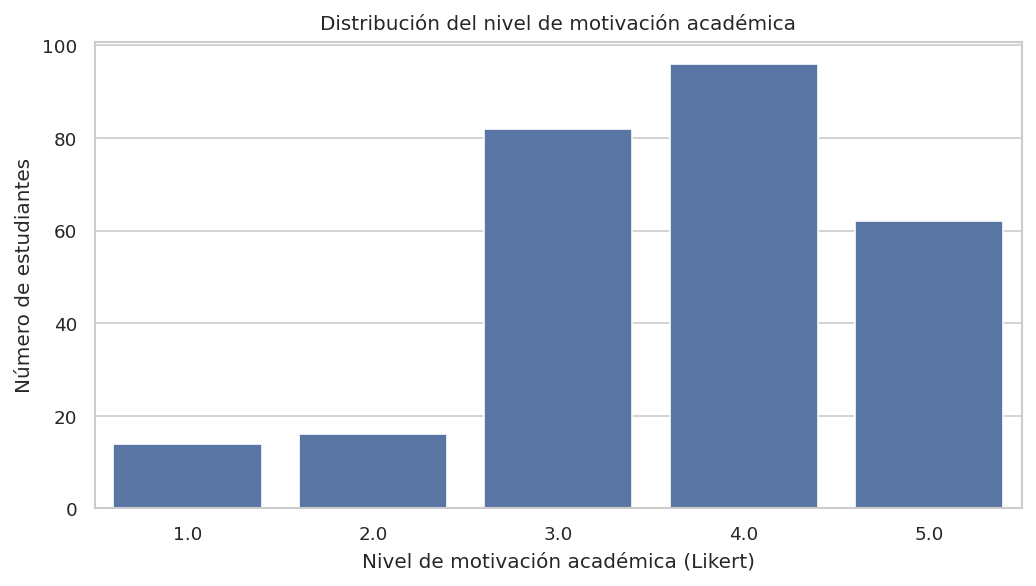

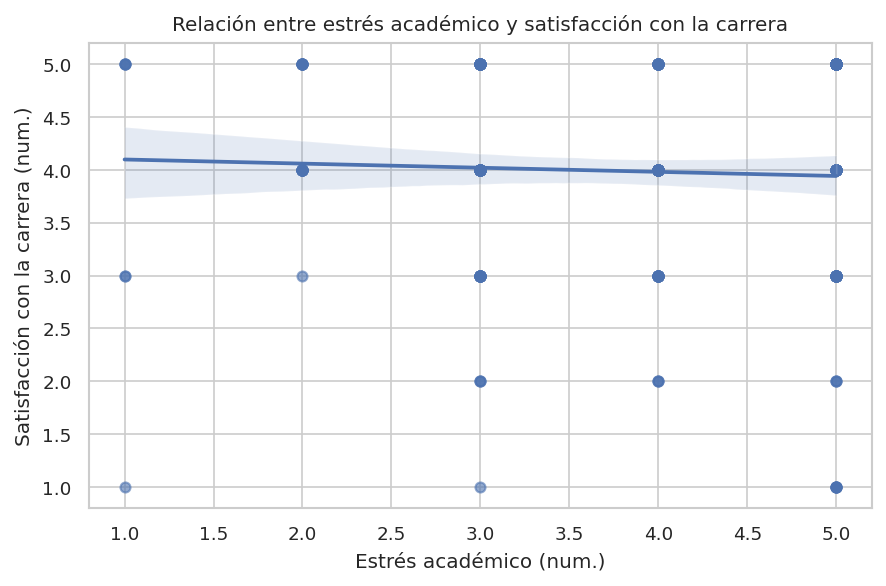

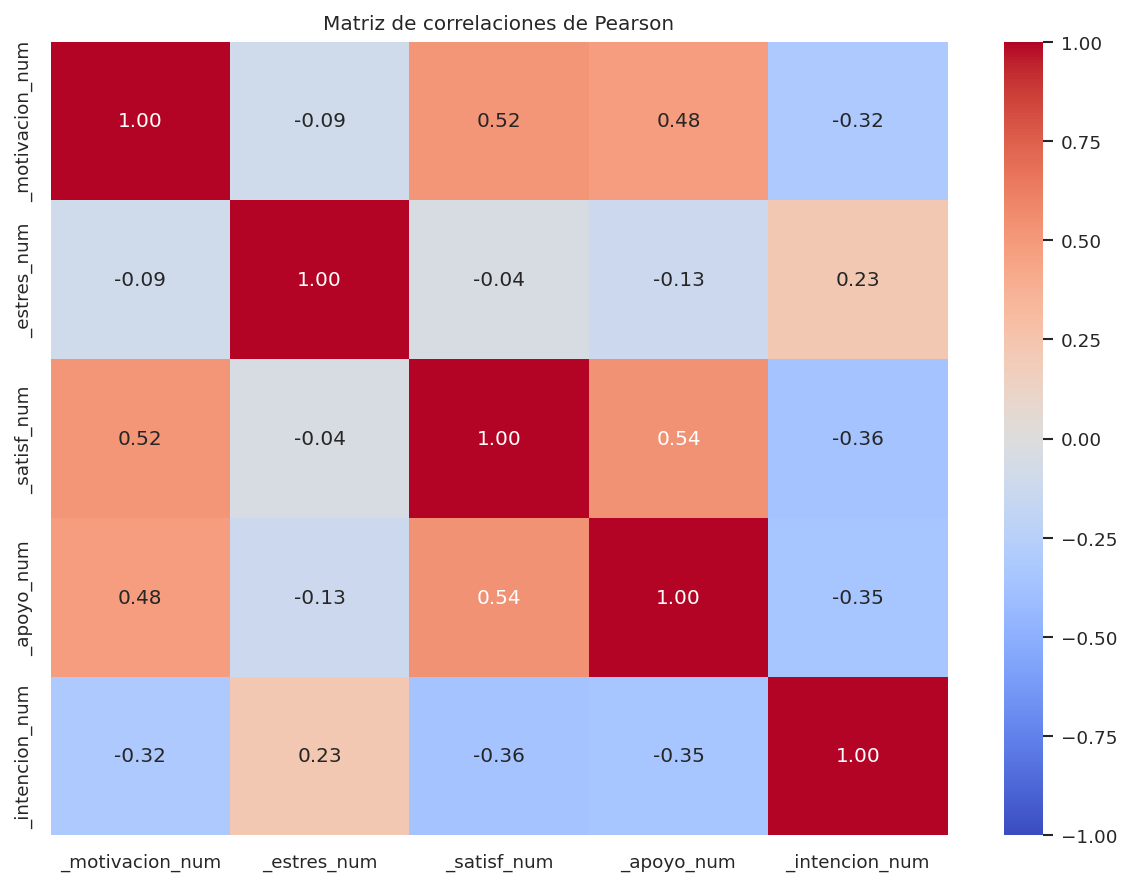

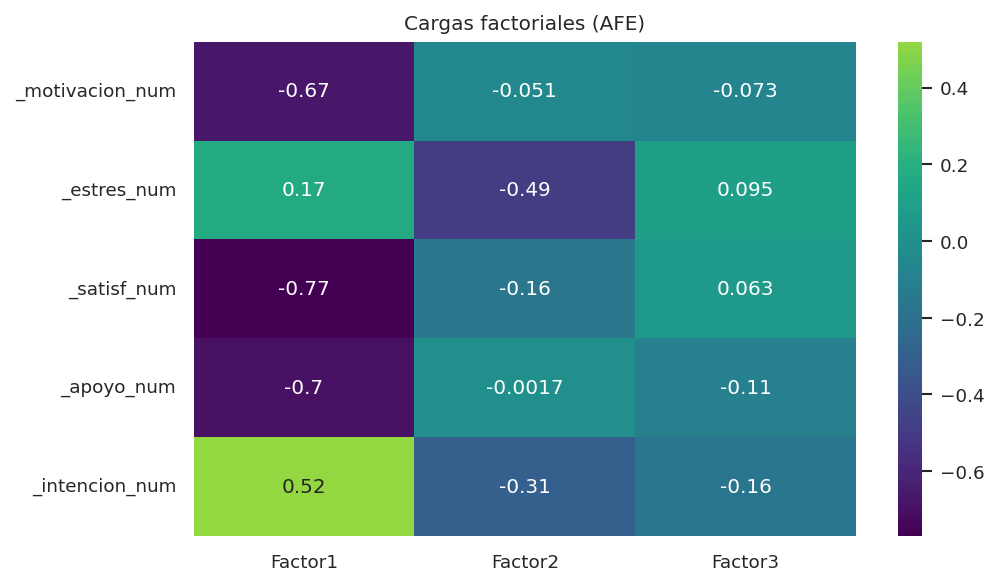


Cargas factoriales:
                   Factor1   Factor2   Factor3
_motivacion_num -0.668359 -0.051253 -0.072620
_estres_num      0.166099 -0.493967  0.094715
_satisf_num     -0.768547 -0.155885  0.062792
_apoyo_num      -0.703836 -0.001660 -0.108498
_intencion_num   0.519866 -0.309575 -0.163532


/tmp/ipython-input-283/249739287.py:219: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(x="_semestre_num", y="_intencion_num", data=df_sem, order=order, ci=68)


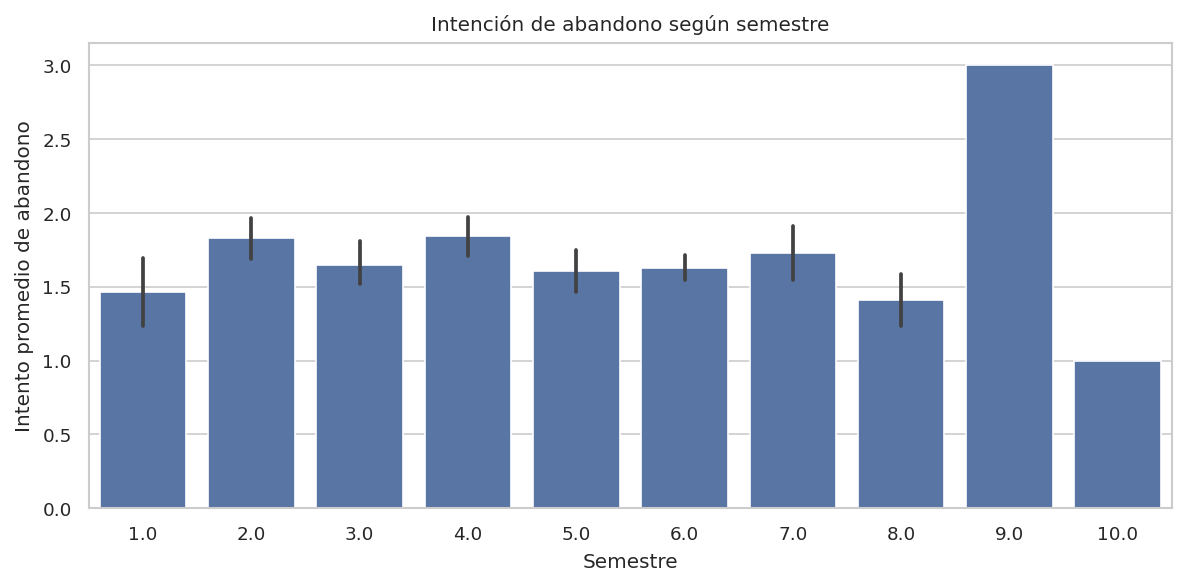


Figuras guardadas en: /content/figuras


In [10]:
# Código listo para Google Colab: generar las figuras del punto 3.5
# Pega todo en una celda y ejecútalo.
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler

# Ajustes visuales (apropiados para publicaciones)
sns.set(style="whitegrid", context="paper", rc={"figure.dpi":150})
plt.rcParams["figure.figsize"] = (7,4)

# 0) Montar drive (opcional)
# from google.colab import drive
# drive.mount('/content/drive')

# 1) Cargar dataset (asegúrate de haber subido dataset_limpio.xlsx a Colab)
file_path = "/content/dataset_limpio.xlsx"   # si lo subes desde UI de Colab, se guardará en /content/
if not os.path.exists(file_path):
    raise FileNotFoundError(f"No encontré {file_path}. Sube dataset_limpio.xlsx al entorno de Colab.")

df = pd.read_excel(file_path)

# 2) Crear carpeta para guardar figuras
out_dir = "/content/figuras"
os.makedirs(out_dir, exist_ok=True)

# 3) Mostrar columnas y tipos (imprime para verificar)
print("Columnas en el dataset:")
for c,dtype in zip(df.columns, df.dtypes):
    print(f" - {c!r} : {dtype}")

# 4) Buscar columnas relevantes usando keywords (robusto a nombres largos)
def find_column_by_keywords(df, keywords):
    cols = df.columns
    keywords = [k.lower() for k in keywords]
    for col in cols:
        low = col.lower()
        if all(k in low for k in keywords):
            return col
    # fallback: return first column that contains any of keywords
    for col in cols:
        low = col.lower()
        if any(k in low for k in keywords):
            return col
    return None

col_motivacion = find_column_by_keywords(df, ["motiv"])
col_estres = find_column_by_keywords(df, ["estres", "estrés", "stress"])
col_satisf = find_column_by_keywords(df, ["satisf", "satisfacción"])
col_apoyo = find_column_by_keywords(df, ["apoyo", "apoy", "instituc"])
col_intencion = find_column_by_keywords(df, ["abandono", "abando", "intencion", "intención"])
col_semestre = find_column_by_keywords(df, ["semest", "nivel", "grado"])

print("\nColumn mapping encontrada:")
print(" motivacion:", col_motivacion)
print(" estres   :", col_estres)
print(" satisf   :", col_satisf)
print(" apoyo    :", col_apoyo)
print(" intencion:", col_intencion)
print(" semestre :", col_semestre)

# 5) Función: intentar convertir columna Likert textual a numérica si hace falta
def ensure_numeric_likert(series):
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float)
    # si es object, intentar map a enteros por patrones comunes
    unique_vals = series.dropna().unique()
    # Common Spanish textual labels mapping (extendible)
    mapping = {
        "muy baja":1, "baja":2, "media":3, "moderada":3, "alta":4, "muy alta":5,
        "muy bajo":1, "muy bajo/a":1, "bajo":2, "medio":3, "alto":4, "muy alto":5,
        "1":1, "2":2, "3":3, "4":4, "5":5
    }
    # Clean strings and map
    s_clean = series.astype(str).str.strip().str.lower()
    # Try direct numeric conversion
    try:
        numeric = pd.to_numeric(s_clean, errors="coerce")
        if numeric.notna().sum() >= 0.6 * len(s_clean):  # si la mayoría convertible
            return numeric.astype(float)
    except:
        pass
    # Map using dictionary if possible
    mapped = s_clean.map(mapping)
    if mapped.notna().sum() >= 0.4 * len(s_clean):
        return mapped.astype(float)
    # As last resort, factorize by frequency order (preserva ordinalidad aproximada)
    vals = s_clean.fillna("NA")
    codes, uniques = pd.factorize(vals)
    # Map codes to 1..k based on ascending order of unique occurrence frequency or lexical
    # We'll map by the order of appearance (not ideal, but better than failing)
    return pd.Series(codes + 1, index=series.index).astype(float)

# 6) Preparar las columnas (si existen)
if col_motivacion is not None:
    df["_motivacion_num"] = ensure_numeric_likert(df[col_motivacion])
else:
    print("Aviso: no se encontró columna de motivación. Saltando gráfico de motivación.")

if col_estres is not None:
    df["_estres_num"] = ensure_numeric_likert(df[col_estres])

if col_satisf is not None:
    df["_satisf_num"] = ensure_numeric_likert(df[col_satisf])

if col_apoyo is not None:
    df["_apoyo_num"] = ensure_numeric_likert(df[col_apoyo])

if col_intencion is not None:
    df["_intencion_num"] = ensure_numeric_likert(df[col_intencion])

# Si semestre no es numérico, dejar como categoría
if col_semestre is not None:
    sem = df[col_semestre].astype(str).str.strip()
    # Normalizar expresiones como "Quinto", "5", "5to"
    def norm_sem(x):
        x_low = x.lower()
        # extraer dígitos
        import re
        m = re.search(r'(\d+)', x_low)
        if m:
            return int(m.group(1))
        # mapping textual básico (español)
        txt_map = {"primero":1,"segundo":2,"tercero":3,"cuarto":4,"quinto":5,"sexto":6,"septimo":7,"séptimo":7,"octavo":8}
        return txt_map.get(x_low, x)
    try:
        df["_semestre_norm"] = sem.map(norm_sem)
    except:
        df["_semestre_norm"] = sem

# --- FIGURA 1: Distribución de motivación (hist + kde o countplot) ---
if "_motivacion_num" in df.columns:
    plt.figure(figsize=(7,4))
    # Si valores son enteros 1..5 usar countplot
    uniq = df["_motivacion_num"].dropna().unique()
    if all(float(x).is_integer() for x in uniq) and max(uniq) <= 10:
        sns.countplot(x="_motivacion_num", data=df, order=sorted(df["_motivacion_num"].dropna().unique()))
        plt.xlabel("Nivel de motivación académica (Likert)")
        plt.ylabel("Número de estudiantes")
    else:
        sns.histplot(data=df, x="_motivacion_num", bins=5, kde=True)
        plt.xlabel("Nivel de motivación académica")
        plt.ylabel("Frecuencia")
    plt.title("Distribución del nivel de motivación académica")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "fig1_motivacion.png"))
    plt.show()

# --- FIGURA 2: Scatter Estrés vs Satisfacción (regresión) ---
if "_estres_num" in df.columns and "_satisf_num" in df.columns:
    plt.figure(figsize=(6,4))
    sns.regplot(data=df, x="_estres_num", y="_satisf_num", scatter_kws={"alpha":0.6})
    plt.xlabel("Estrés académico (num.)")
    plt.ylabel("Satisfacción con la carrera (num.)")
    plt.title("Relación entre estrés académico y satisfacción con la carrera")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "fig2_estres_vs_satisf.png"))
    plt.show()

# --- FIGURA 3: Matriz de correlaciones (Pearson) ---
# Elegir variables numéricas relevantes detectadas
num_vars = []
for c in ["_motivacion_num","_estres_num","_satisf_num","_apoyo_num","_intencion_num"]:
    if c in df.columns:
        num_vars.append(c)

if len(num_vars) >= 2:
    corr = df[num_vars].corr(method="pearson")
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", square=False)
    plt.title("Matriz de correlaciones de Pearson")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "fig3_correlaciones.png"))
    plt.show()
else:
    print("No hay suficientes variables numéricas detectadas para calcular correlaciones.")

# --- FIGURA 4: Análisis Factorial Exploratorio (AFE) - cargas factoriales ---
# Seleccionar variables numéricas (al menos 4 para tener sentido)
afe_vars = num_vars.copy()
# evitar usar la intencion si se quiere como resultado; lo dejamos igual si está presente
if len(afe_vars) >= 4:
    # Remover filas con NA en esas columnas
    X = df[afe_vars].dropna()
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    # Elegir componentes (p.ej. 3) - puedes ajustar n_components
    n_comp = min(3, Xs.shape[1])
    fa = FactorAnalysis(n_components=n_comp, random_state=0)
    fa.fit(Xs)
    loadings = pd.DataFrame(fa.components_.T, index=afe_vars, columns=[f"Factor{i+1}" for i in range(n_comp)])
    plt.figure(figsize=(7, max(4, len(afe_vars)*0.6)))
    sns.heatmap(loadings, annot=True, cmap="viridis", center=0)
    plt.title("Cargas factoriales (AFE)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "fig4_afe_cargas.png"))
    plt.show()
    print("\nCargas factoriales:\n", loadings)
else:
    print("No hay suficientes variables para AFE (se recomiendan >=4 variables numéricas).")

# --- FIGURA 5: Intención de abandono por semestre (media por semestre) ---
if "_intencion_num" in df.columns and "_semestre_norm" in df.columns:
    # Intentar convertir semestre a numérico donde sea posible
    try:
        sem_vals = pd.to_numeric(df["_semestre_norm"], errors="coerce")
        df["_semestre_num"] = sem_vals
    except:
        df["_semestre_num"] = df["_semestre_norm"]

    # Agrupar por semestre y calcular media
    df_sem = df.dropna(subset=["_semestre_num","_intencion_num"])
    if not df_sem.empty:
        order = sorted(df_sem["_semestre_num"].unique(), key=lambda x: float(x) if str(x).replace('.','',1).isdigit() else x)
        plt.figure(figsize=(8,4))
        sns.barplot(x="_semestre_num", y="_intencion_num", data=df_sem, order=order, ci=68)
        plt.xlabel("Semestre")
        plt.ylabel("Intento promedio de abandono")
        plt.title("Intención de abandono según semestre")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "fig5_intencion_por_semestre.png"))
        plt.show()
    else:
        print("No se encontraron pares semestre-intención válidos.")
else:
    print("No se puede graficar intención por semestre: faltan columnas detectadas.")

print(f"\nFiguras guardadas en: {out_dir}")
